# VC-Genome Full Pipeline: All 520 Images

Processes all 520 images from `image_compiled_phrases.csv` using Claude vision-based extractions.

**Stage 1:** Load vision extractions from `vc_genome_output_full/llm_extractions_vision.json`  
**Stage 2:** Canonicalize against ontology (multi-level fallback matching)  
**Stage 3:** Build scene graphs, compute metrics, save SVGs (no inline display)  

All outputs saved to `vc_genome_output_full/`.

In [11]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import os, sys, json, graphviz
from pathlib import Path
from collections import defaultdict, Counter
from IPython.display import display

pd.set_option('display.max_colwidth', 120)

# Graphviz setup for Windows
os.environ['PATH'] = r'C:\Program Files (x86)\Graphviz\bin;' + os.environ.get('PATH', '')
os.environ['PANGOCAIRO_BACKEND'] = 'fontconfig'
os.environ['FONTCONFIG_FILE'] = os.devnull  # suppress "Cannot load default config" warning

# Output directories
OUT_DIR   = Path('vc_genome_output_full')
GRAPH_DIR = OUT_DIR / 'graphs'   # SVGs — gitignored
PNG_DIR   = OUT_DIR / 'images'   # PNGs — tracked in git
OUT_DIR.mkdir(exist_ok=True)
GRAPH_DIR.mkdir(exist_ok=True)

PNG_DIR.mkdir(exist_ok=True)
print(f'Output dir: {OUT_DIR.resolve()}')

Output dir: D:\Coding\Copilot\comment_post_processing\vc_genome_output_full


## Load Data

In [2]:
compiled     = pd.read_csv('phrase_reduction_v2/image_compiled_phrases.csv')
subtopics_df = pd.read_csv('phrase_reduction_v2/phrase_shortlist.csv')

print(f'Total images in dataset: {len(compiled)}')
print(f'VisTypes: {sorted(compiled["VisType"].unique())}')
print(f'VC range: {compiled["NormalizedVC"].min():.2f} – {compiled["NormalizedVC"].max():.2f}')

Total images in dataset: 520
VisTypes: ['Area', 'Area and Text', 'Bar', 'Bar and point', 'Cont.-ColorPatn', 'Glyph', 'Grid', 'Line', 'Node-link', 'Point', 'Schematic', 'Table', 'Text']
VC range: 0.15 – 0.95


## Stage 1: Load Vision Extractions

In [3]:
EXTRACTIONS_FILE = Path('vc_genome_output_full/llm_extractions_vision.json')

with open(EXTRACTIONS_FILE, 'r', encoding='utf-8') as f:
    stage1_extractions = json.load(f)

print(f'Extractions available: {len(stage1_extractions)} / {len(compiled)}')

# Only process images that have extractions
images_df = compiled[compiled['imageName'].isin(stage1_extractions)].copy().reset_index(drop=True)
missing   = compiled[~compiled['imageName'].isin(stage1_extractions)]['imageName'].tolist()

print(f'Images to process:      {len(images_df)}')
if missing:
    print(f'Missing extractions ({len(missing)}): run _extract_stage2_vision.py to complete.')

Extractions available: 520 / 520
Images to process:      520


## Stage 2: Canonicalization

In [5]:
OBJECT_SYNSETS = {
    # ── Marks ──
    'bar': 'mark.bar', 'bars': 'mark.bar', 'bar_chart': 'mark.bar',
    'stacked_bar': 'mark.bar', 'bar_segment': 'mark.bar',
    'dot': 'mark.point', 'point': 'mark.point', 'data_point': 'mark.point',
    'data_points': 'mark.point', 'dots': 'mark.point', 'scatter_points': 'mark.point',
    'circle': 'mark.point', 'circles': 'mark.point', 'bubble': 'mark.point',
    'shape': 'mark.shape', 'shapes': 'mark.shape',
    'line': 'mark.line', 'lines': 'mark.line', 'vertical_line': 'mark.line',
    'connecting_line': 'mark.line', 'connecting_lines': 'mark.line',
    'curved_lines': 'mark.line', 'dashed_line': 'mark.line',
    'grid_lines': 'mark.line', 'line_curve': 'mark.line',
    'color_segment': 'mark.color_segment', 'color_segments': 'mark.color_segment',
    'color_bands': 'mark.color_segment', 'color_regions': 'mark.color_segment',
    'glyph': 'mark.glyph', 'glyphs': 'mark.glyph',
    'node': 'mark.node', 'nodes': 'mark.node', 'node_cluster': 'mark.node',
    'edge': 'structure.link', 'edges': 'structure.link',
    'area': 'mark.area', 'area_marks': 'mark.area', 'area_shape': 'mark.area',
    'area_chart': 'mark.area', 'stacked_area_chart': 'mark.area',
    'symbol': 'mark.symbol', 'icon': 'mark.symbol', 'arrow': 'mark.symbol',
    'element': 'mark.element', 'object': 'mark.element',
    # ── Properties ──
    'color': 'property.color', 'color_shading': 'property.color',
    'color_encoding': 'property.color', 'color_pattern': 'property.color',
    'color_palette': 'property.color', 'color_scheme': 'property.color',
    'color_gradient': 'property.color', 'color_fill': 'property.color',
    'color_scale': 'property.color', 'color_overlay': 'property.color',
    'color_variety': 'property.color',
    'font_size': 'property.font_size',
    'encoding': 'property.encoding', 'visual_encoding': 'property.encoding',
    'data_encoding': 'property.encoding',
    # ── Structure ──
    'box': 'structure.panel', 'bounding_box': 'structure.panel',
    'layout': 'structure.layout', 'overall_layout': 'structure.layout',
    'layout_structure': 'structure.layout',
    'pattern': 'structure.pattern', 'data_pattern': 'structure.pattern',
    'flow_pattern': 'structure.pattern',
    'connection': 'structure.link', 'link': 'structure.link',
    'grid': 'structure.grid', 'grid_cells': 'structure.grid',
    'heatmap_grid': 'structure.grid',
    'cell': 'structure.cell',
    'region': 'structure.region', 'data_area': 'structure.region',
    'zoom_inset': 'structure.region',
    'background': 'structure.background', 'map_background': 'structure.background',
    # ── Text ──
    'title': 'text.title', 'title_label': 'text.title',
    'description': 'text.description', 'caption': 'text.description',
    'axis_label': 'text.axis_label', 'axis_labels': 'text.axis_label',
    'y_axis_label': 'text.axis_label', 'x_axis_label': 'text.axis_label',
    'label': 'text.label', 'labels': 'text.label', 'text_labels': 'text.label',
    'text_label': 'text.label', 'label_text': 'text.label',
    'node_label': 'text.label', 'node_labels': 'text.label',
    'country_label': 'text.label', 'country_labels': 'text.label',
    'street_labels': 'text.label',
    'text': 'text.label', 'text_content': 'text.label',
    'small_text': 'text.label', 'text_words': 'text.label',
    'large_words': 'text.label', 'explanation_text': 'text.label',
    'words': 'text.label',
    'annotation': 'text.annotation', 'annotation_text': 'text.annotation',
    'annotation_label': 'text.annotation', 'annotation_labels': 'text.annotation',
    'number': 'content.number', 'numbers': 'content.number',
    # ── Furniture ──
    'legend': 'furniture.legend', 'color_code': 'furniture.legend',
    'color_legend': 'furniture.legend',
    'axes': 'furniture.axes', 'x_axis': 'furniture.axes', 'y_axis': 'furniture.axes',
    'axis': 'furniture.axes',
    # ── Whole (vis types as objects) ──
    'visualization': 'whole.visualization', 'chart': 'whole.visualization',
    'chart_structure': 'whole.visualization',
    'graph': 'whole.visualization', 'image': 'whole.visualization',
    'map': 'whole.visualization', 'world_map': 'whole.visualization',
    'scatter_plot': 'whole.visualization', 'line_chart': 'whole.visualization',
    'pie_chart': 'whole.visualization', 'word_cloud': 'whole.visualization',
    'node_link_diagram': 'whole.visualization', 'node_link_graph': 'whole.visualization',
    'network_graph': 'whole.visualization',
    # ── Content ──
    'data': 'content.data', 'information': 'content.data',
    'knowledge': 'content.domain', 'concept': 'content.domain',
    'detail': 'content.detail',
}

# Component-based suffix→synset for fallback matching
_SUFFIX_MAP = {
    'chart': 'whole.visualization', 'plot': 'whole.visualization',
    'diagram': 'whole.visualization', 'graph': 'whole.visualization',
    'map': 'whole.visualization', 'cloud': 'whole.visualization',
    'legend': 'furniture.legend',
    'axis': 'furniture.axes', 'axes': 'furniture.axes',
    'label': 'text.label', 'labels': 'text.label',
    'text': 'text.label', 'title': 'text.title',
    'annotation': 'text.annotation', 'caption': 'text.description',
    'line': 'mark.line', 'lines': 'mark.line',
    'bar': 'mark.bar', 'bars': 'mark.bar',
    'node': 'mark.node', 'nodes': 'mark.node',
    'point': 'mark.point', 'points': 'mark.point',
    'dot': 'mark.point', 'dots': 'mark.point',
    'circle': 'mark.point', 'circles': 'mark.point',
    'area': 'mark.area',
    'grid': 'structure.grid', 'cell': 'structure.cell', 'cells': 'structure.cell',
    'layout': 'structure.layout', 'region': 'structure.region',
    'background': 'structure.background',
    'color': 'property.color', 'gradient': 'property.color',
    'encoding': 'property.encoding',
    'pattern': 'structure.pattern',
    'link': 'structure.link', 'edge': 'structure.link', 'edges': 'structure.link',
    'data': 'content.data',
}


def resolve_object_synset(name):
    """Multi-level fallback: exact → last component → first component → unknown."""
    # Level 1: exact match
    if name in OBJECT_SYNSETS:
        return OBJECT_SYNSETS[name]
    # Level 2: split on '_', try last component (head noun)
    parts = name.split('_')
    if len(parts) > 1:
        if parts[-1] in _SUFFIX_MAP:
            return _SUFFIX_MAP[parts[-1]]
        # Level 3: try first component (modifier that may be a known entity)
        if parts[0] in OBJECT_SYNSETS:
            return OBJECT_SYNSETS[parts[0]]
    # Level 4: strip trailing 's' for simple plurals
    if name.endswith('s') and name[:-1] in OBJECT_SYNSETS:
        return OBJECT_SYNSETS[name[:-1]]
    return f'unknown.{name}'


PREDICATE_CANON = {
    # Core relationships
    'describes': 'describes', 'labels': 'describes', 'annotates': 'describes',
    'clarifies': 'clarifies', 'clarifies_meaning_of': 'clarifies',
    'provides_context_for': 'clarifies',
    'encodes_via': 'encodes_via',
    'fills': 'fills',
    'overlaps_with': 'overlaps_with', 'overlaps': 'overlaps_with',
    'overlap': 'overlaps_with', 'overlays': 'overlaps_with',
    'varies_across': 'varies_across', 'varies_in_size': 'varies_across',
    'connects': 'connects', 'connects_to': 'connects',
    'combines_with': 'co_occurs_with', 'coexists_with': 'co_occurs_with',
    'mixed_with': 'co_occurs_with',
    # Negative / complexity
    'clutters': 'clutters', 'clutter': 'clutters',
    'obscures': 'obscures', 'obscures_meaning_of': 'obscures',
    'overwhelms': 'overwhelms',
    'confuses': 'confuses', 'confuse': 'confuses',
    'confuses_interpretation_of': 'confuses',
    'increases': 'increases_complexity',
    'increases_complexity_of': 'increases_complexity',
    'increases_difficulty_of': 'increases_complexity',
    'increases_visual_complexity': 'increases_complexity',
    'adds_complexity_to': 'increases_complexity',
    'increases_processing_effort': 'increases_effort',
    'increases_processing_time': 'increases_effort',
    'increases_reading_effort': 'increases_effort',
    'increases_reading_difficulty': 'increases_effort',
    'increases_interpretive_difficulty': 'increases_effort',
    'increases_interpretive_load_of': 'increases_effort',
    'increases_cognitive_load': 'increases_effort',
    'increases_density_of': 'increases_complexity',
    'increases_ambiguity_of': 'increases_ambiguity',
    'reduces_readability_of': 'hinders_reading',
    'reduces_distinguishability_of': 'hinders_reading',
    'requires_effort_to_read': 'hinders_reading',
    'hinders_interpretation_of': 'hinders_reading',
    'hinders_understanding_of': 'hinders_reading',
    'fails_to_explain': 'fails_to_explain',
    'fails_to_decode': 'fails_to_decode', 'fails_to_clarify': 'fails_to_clarify',
    'lacks_context_for': 'lacks', 'lacks': 'lacks',
    'lacks_story': 'lacks', 'missing_from': 'missing_from',
    'is_missing_from': 'missing_from',
    # Positive / structural
    'aids_interpretation_of': 'aids_interpretation',
    'supports_readability_of': 'aids_interpretation',
    'facilitates_reading_of': 'aids_interpretation',
    'reduces_complexity_of': 'simplifies', 'simplifies': 'simplifies',
    'simplify': 'simplifies',
    'organizes': 'structures', 'structures': 'structures',
    'contains': 'contains', 'contains_many': 'contains',
    'surrounds': 'contains', 'underlies': 'contains',
    # Cognitive / perceptual
    'requires_expertise': 'requires_expertise',
    'requires_domain_knowledge': 'requires_expertise',
    'distracts_from': 'distracts',
    'scattered_across': 'distributed_across', 'distributed_across': 'distributed_across',
    'spreads_across': 'distributed_across',
    'differentiates': 'differentiates', 'contrasts_with': 'differentiates',
    'contrasts_against': 'differentiates',
    # Representation
    'represent': 'represents', 'represents': 'represents',
    'show': 'represents', 'display': 'represents', 'forms': 'represents',
    'indicate': 'indicates', 'indicates': 'indicates',
    'suggests_uncertain': 'suggests_uncertain',
    'identify': 'identifies', 'identifies': 'identifies',
    'distinguish': 'distinguishes', 'distinguishes': 'distinguishes',
    # Interpretation
    'understand': 'interpreted_via', 'interpret': 'interpreted_via',
    'read': 'interpreted_via',
    'compare': 'compared_with', 'compared_with': 'compared_with',
    'more_complex_than': 'compared_with', 'resembles': 'compared_with',
    # Spatial
    'contributes_to': 'contributes_to', 'creates': 'contributes_to',
    'makes_hard_to_discern': 'obscures',
}


def resolve_predicate(pred):
    """Multi-level predicate resolution: exact → suffix-stripped → pass-through."""
    if pred in PREDICATE_CANON:
        return PREDICATE_CANON[pred]
    # Try stripping common suffixes like _of, _for
    for suffix in ('_of', '_for', '_to', '_from'):
        stem = pred.rsplit(suffix, 1)[0]
        if stem in PREDICATE_CANON:
            return PREDICATE_CANON[stem]
    # Pass through as-is (already descriptive)
    return pred


def canonicalize(extraction):
    """Canonicalize raw extraction into ontology-aligned form."""
    canon  = {'objects': [], 'attributes': [], 'relationships': []}
    id_map = {}
    for obj in extraction['objects']:
        synset = resolve_object_synset(obj['name'])
        id_map[obj['id']] = synset
        canon['objects'].append({
            'id': obj['id'], 'name': obj['name'],
            'synset': synset, 'region': obj['region']
        })
    for attr in extraction['attributes']:
        oid = attr['object_id']
        if oid not in id_map:
            continue
        canon['attributes'].append({
            'object_id': oid, 'object_synset': id_map[oid],
            'attr': attr.get('attr', attr.get('name', 'unknown')),
            'sentiment': attr['sentiment'],
            'subtopic': attr['subtopic'],
        })
    for rel in extraction['relationships']:
        subj_id = rel.get('subj')
        obj_id = rel.get('obj')
        if subj_id not in id_map or obj_id not in id_map:
            continue
        canon['relationships'].append({
            'subject_synset': id_map[subj_id],
            'predicate': resolve_predicate(rel['pred']),
            'object_synset': id_map[obj_id],
            'sentiment': rel.get('sentiment', '+'),
            'subtopic': rel.get('subtopic', 'Unknown'),
        })
    return canon


stage2_canonical = {img: canonicalize(ext) for img, ext in stage1_extractions.items()}

# Coverage report
total_obj = sum(len(ext['objects']) for ext in stage1_extractions.values())
mapped_obj = sum(1 for ext in stage1_extractions.values()
                 for o in ext['objects'] if not resolve_object_synset(o['name']).startswith('unknown.'))
total_pred = sum(len(ext['relationships']) for ext in stage1_extractions.values())

def _pred_is_mapped(p):
    if p in PREDICATE_CANON:
        return True
    for sfx in ('_of', '_for', '_to', '_from'):
        if p.rsplit(sfx, 1)[0] in PREDICATE_CANON:
            return True
    return False

mapped_pred = sum(1 for ext in stage1_extractions.values()
                  for r in ext['relationships'] if _pred_is_mapped(r['pred']))

print(f'Canonicalized {len(stage2_canonical)} images')
print(f'Object coverage:    {mapped_obj}/{total_obj} ({mapped_obj/total_obj*100:.1f}%)')
print(f'Predicate coverage: {mapped_pred}/{total_pred} ({mapped_pred/total_pred*100:.1f}%)')

Canonicalized 520 images
Object coverage:    1528/1810 (84.4%)
Predicate coverage: 589/1033 (57.0%)


## Stage 3: Build Scene Graphs, Compute Metrics & Save SVGs

In [17]:
SUBTOPIC_TO_TOPIC = dict(zip(subtopics_df['SubTopic'], subtopics_df['Topic']))
COLOR_OBJECT    = '#b8e6b8'
COLOR_ATTR_POS  = '#c7b8e6'   # darker purple for (+)
COLOR_ATTR_NEG  = '#e8dff5'   # lighter purple for (−)
COLOR_RELATION  = '#f5b8b8'
UNDIRECTED_PREDS = {'co_occurs_with', 'overlaps_with'}


def build_scene_graph(canon_data, image_name):
    G = nx.DiGraph()
    G.graph['image'] = image_name
    for obj in canon_data['objects']:
        G.add_node(obj['synset'], label=obj['name'], synset=obj['synset'],
                   region=obj['region'], node_type='object',
                   attributes=[], sentiments=[])
    for attr in canon_data['attributes']:
        nid = attr['object_synset']
        if nid in G:
            G.nodes[nid]['attributes'].append(attr['attr'])
            G.nodes[nid]['sentiments'].append(attr['sentiment'])
    for rel in canon_data['relationships']:
        G.add_edge(rel['subject_synset'], rel['object_synset'],
                   predicate=rel['predicate'], sentiment=rel['sentiment'],
                   subtopic=rel['subtopic'],
                   topic=SUBTOPIC_TO_TOPIC.get(rel['subtopic'], 'Unknown'))
    return G


def compute_graph_metrics(G):
    n_nodes = G.number_of_nodes()
    n_edges = G.number_of_edges()
    all_sents  = [s for n in G.nodes for s in G.nodes[n].get('sentiments', [])]
    all_sents += [G.edges[e]['sentiment'] for e in G.edges]
    n_attrs = sum(len(G.nodes[n].get('attributes', [])) for n in G.nodes)
    n_pos   = sum(1 for s in all_sents if s == '+')
    n_neg   = sum(1 for s in all_sents if s == '-')
    subtopics_hit = set(G.edges[e].get('subtopic', '') for e in G.edges)
    regions = set(G.nodes[n].get('region', '') for n in G.nodes)
    max_edges = n_nodes * (n_nodes - 1) if n_nodes > 1 else 1
    return {
        'nodes': n_nodes, 'edges': n_edges, 'attributes': n_attrs,
        'attr_density':    round(n_attrs / max(n_nodes, 1), 2),
        'edge_density':    round(n_edges / max_edges, 3),
        'positive_count':  n_pos, 'negative_count': n_neg,
        'positive_ratio':  round(n_pos / max(len(all_sents), 1), 2),
        'subtopics_covered': len(subtopics_hit),
        'regions_used':    len(regions),
    }


def build_vg_graphviz(canon_data, image_name, vc, vistype):
    dot = graphviz.Digraph(
        name=image_name, format='svg',
        graph_attr={'rankdir': 'LR', 'fontsize': '10', 'fontname': 'Arial',
                    'nodesep': '0.4', 'ranksep': '0.6', 'splines': 'true', 'bgcolor': 'white',
                    'dpi': '150'},
        node_attr={'fontname': 'Arial', 'fontsize': '10', 'shape': 'box',
                   'style': 'rounded,filled', 'penwidth': '1.2'},
        edge_attr={'fontname': 'Arial', 'fontsize': '9', 'color': '#888888'},
    )
    attrs_by_obj = defaultdict(list)
    for i, attr in enumerate(canon_data['attributes']):
        sent  = '(+)' if attr['sentiment'] == '+' else '(\u2212)'
        label = f"{sent} {attr['attr'].replace('_', ' ')[:30]}"
        color = COLOR_ATTR_POS if attr['sentiment'] == '+' else COLOR_ATTR_NEG
        attrs_by_obj[attr['object_synset']].append((f'attr_{i}', label, color))

    for obj in canon_data['objects']:
        dot.node(obj['synset'], label=obj['name'].replace('_', ' '),
                 fillcolor=COLOR_OBJECT, color='#2c3e50', fontcolor='#1a1a1a', penwidth='1.8')
    for obj in canon_data['objects']:
        for attr_id, attr_label, attr_color in attrs_by_obj.get(obj['synset'], []):
            dot.node(attr_id, label=attr_label, fillcolor=attr_color,
                     color='#7f8c8d', fontcolor='#1a1a1a')
            dot.edge(obj['synset'], attr_id, color='#aaaaaa', arrowsize='0.7')

    for ri, rel in enumerate(canon_data['relationships']):
        pred_id = f'rel_{ri}'
        dot.node(pred_id, label=rel['predicate'].replace('_', ' '),
                 fillcolor=COLOR_RELATION, color='#d46a6a', fontcolor='#8b0000')
        dot.edge(rel['subject_synset'], pred_id, color='#d46a6a', penwidth='1.5', arrowsize='0.8')
        if rel['predicate'] in UNDIRECTED_PREDS:
            dot.edge(pred_id, rel['object_synset'], color='#d46a6a',
                     penwidth='1.5', style='dashed', arrowhead='none')
        else:
            dot.edge(pred_id, rel['object_synset'], color='#d46a6a', penwidth='1.5', arrowsize='0.8')

    title_html = f'''<
    <TABLE BORDER="0" CELLBORDER="0" CELLSPACING="2" CELLPADDING="2">
    <TR><TD COLSPAN="8" ALIGN="CENTER"><B><FONT POINT-SIZE="14">{image_name}</FONT></B></TD></TR>
    <TR><TD COLSPAN="8" ALIGN="CENTER"><FONT POINT-SIZE="11">{vistype}  |  VC = {vc:.2f}</FONT></TD></TR>
    <TR>
      <TD BGCOLOR="#b8e6b8" BORDER="1" STYLE="rounded" WIDTH="20"> </TD><TD>Object</TD>
      <TD BGCOLOR="#c7b8e6" BORDER="1" STYLE="rounded" WIDTH="20"> </TD><TD>Attr (+)</TD>
      <TD BGCOLOR="#e8dff5" BORDER="1" STYLE="rounded" WIDTH="20"> </TD><TD>Attr (\u2212)</TD>
      <TD BGCOLOR="#f5b8b8" BORDER="1" STYLE="rounded" WIDTH="20"> </TD><TD>Relationship</TD>
    </TR>
    </TABLE>>'''
    dot.attr(label=title_html, labelloc='t', labeljust='c')
    return dot

Saved test PNG: vc_genome_output_full\images\economist_daily_chart_317.png
PNG size: 225,206 bytes (219.9 KB)
SVG size: 23,780 bytes (23.2 KB)


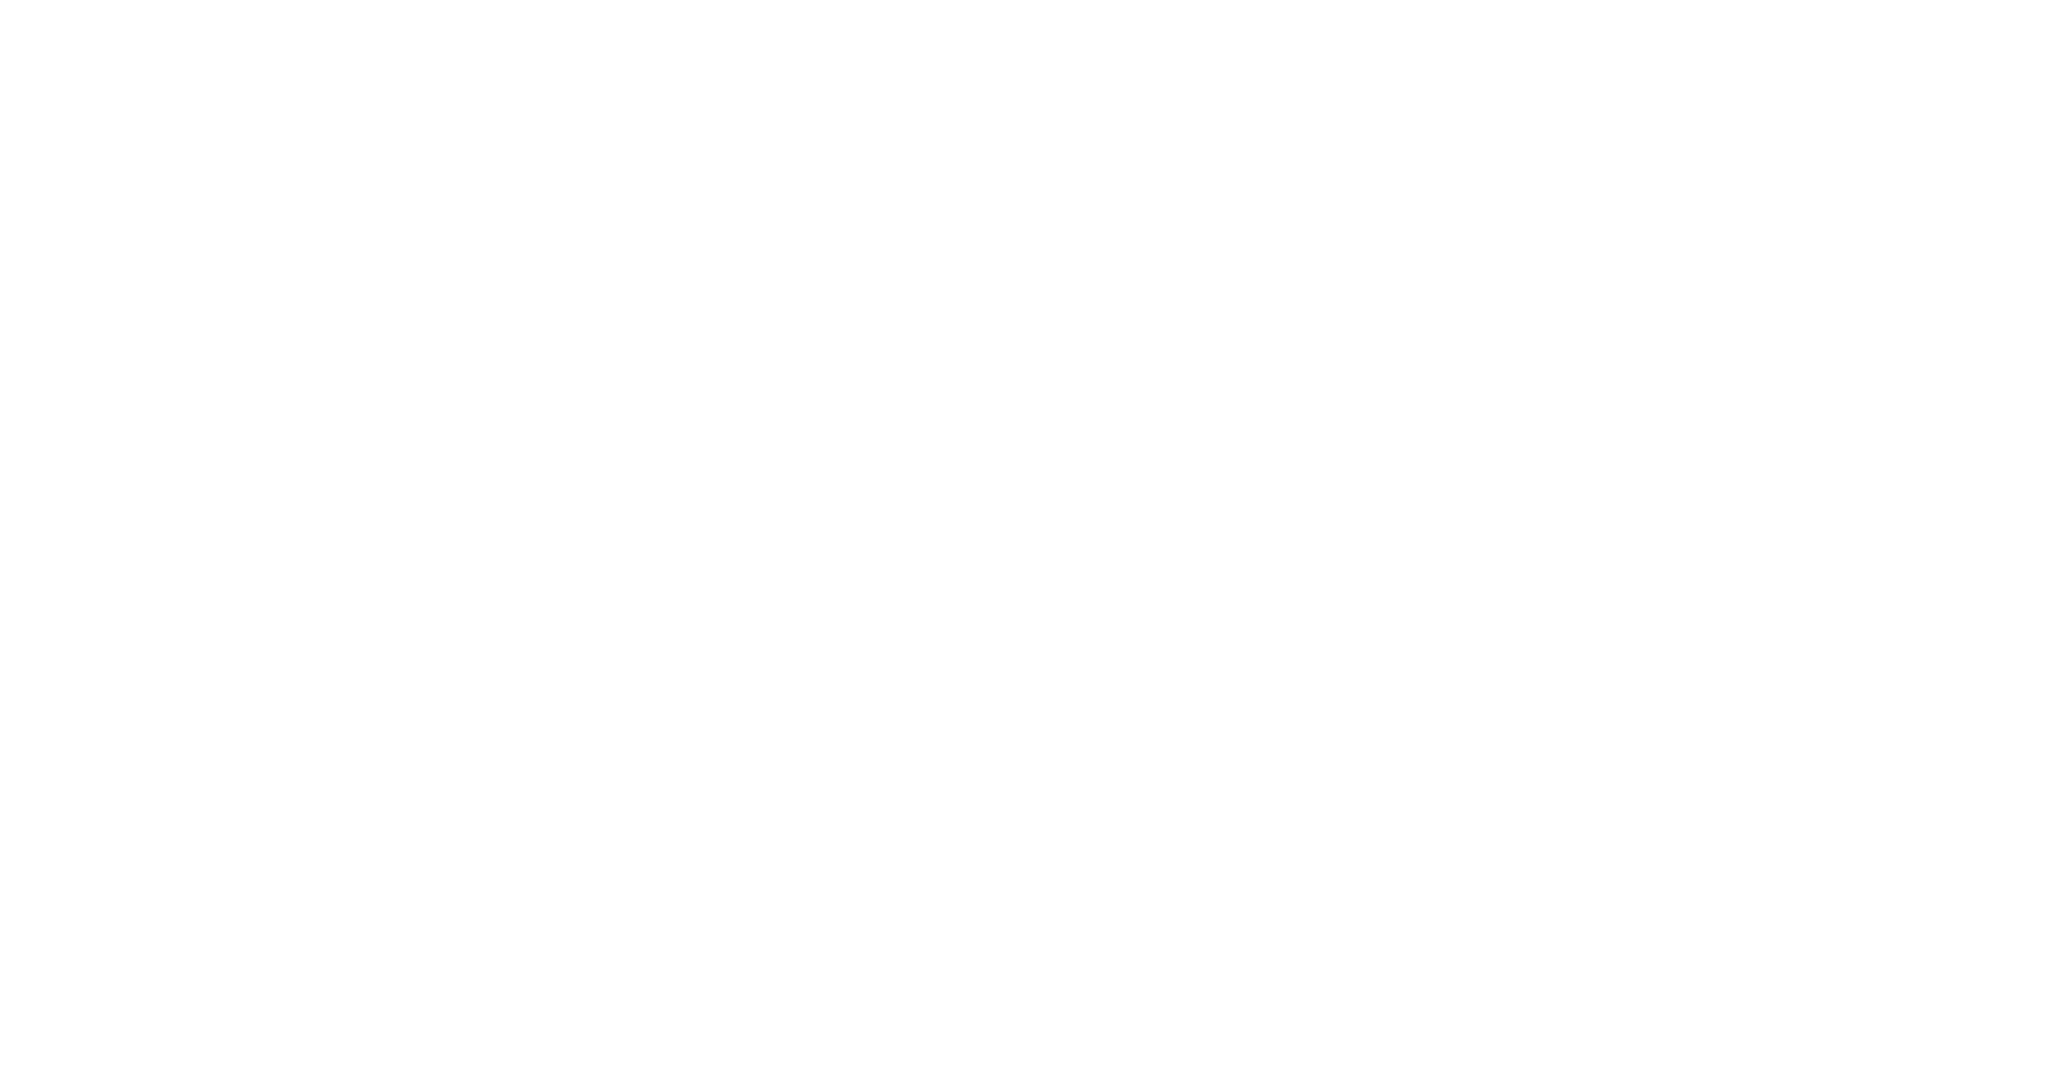

In [18]:
# --- Test: render one graph and save to check file size ---
from IPython.display import SVG

test_img = 'economist_daily_chart_317.png'
test_row = compiled[compiled['imageName'] == test_img].iloc[0]
test_canon = stage2_canonical[test_img]

dot = build_vg_graphviz(test_canon, test_img, test_row['NormalizedVC'], test_row['VisType'])

# Render (suppress fontconfig warning)
_stderr = sys.stderr
sys.stderr = open(os.devnull, 'w')
try:
    svg_bytes = dot.pipe(format='svg')
    png_bytes = dot.pipe(format='png')
finally:
    sys.stderr.close()
    sys.stderr = _stderr

# Save to disk so we can check file size
test_png_path = PNG_DIR / f'{test_img.removesuffix(".png")}.png'
test_png_path.write_bytes(png_bytes)
print(f'Saved test PNG: {test_png_path}')
print(f'PNG size: {len(png_bytes):,} bytes ({len(png_bytes)/1024:.1f} KB)')
print(f'SVG size: {len(svg_bytes):,} bytes ({len(svg_bytes)/1024:.1f} KB)')

# Display inline (constrained width)
svg_str = svg_bytes.decode('utf-8').replace(
    '<svg ', '<svg style="max-width:900px;height:auto" ', 1)
SVG(data=svg_str)

In [19]:
# Process all images
metrics_rows = []
n_total = len(images_df)

for i, (_, row) in enumerate(images_df.iterrows(), 1):
    img   = row['imageName']
    canon = stage2_canonical[img]
    G     = build_scene_graph(canon, img)
    m     = compute_graph_metrics(G)
    metrics_rows.append({'imageName': img, 'VisType': row['VisType'],
                         'NormalizedVC': row['NormalizedVC'], **m})

    dot = build_vg_graphviz(canon, img, row['NormalizedVC'], row['VisType'])
    safe_name = img.removesuffix('.png')

    _stderr = sys.stderr
    sys.stderr = open(os.devnull, 'w')
    try:
        svg_data = dot.pipe(format='svg')
        png_data = dot.pipe(format='png')
    finally:
        sys.stderr.close()
        sys.stderr = _stderr

    (GRAPH_DIR / f'{safe_name}.svg').write_bytes(svg_data)
    (PNG_DIR   / f'{safe_name}.png').write_bytes(png_data)

    if i % 50 == 0 or i == n_total:
        print(f'  [{i}/{n_total}] last saved: {img}')

# Save metrics CSV
metrics_df = pd.DataFrame(metrics_rows)

metrics_df.to_csv(OUT_DIR / 'graph_metrics.csv', index=False)
print(f'Saved {len(metrics_rows)} PNGs to {PNG_DIR}/')

print(f'\nSaved {len(metrics_df)} rows to {OUT_DIR}/graph_metrics.csv')
print(f'Saved {len(metrics_rows)} SVGs to {GRAPH_DIR}/')

  [50/520] last saved: InfoVisJ.1634.1.png
  [100/520] last saved: VASTC.72.13.png
  [150/520] last saved: VisC.175.1(3).png
  [200/520] last saved: SciVisJ.980.9.png
  [250/520] last saved: VASTC.41.5.png
  [300/520] last saved: InfoVisC.103.9.png
  [350/520] last saved: VisC.11.12(2).png
  [400/520] last saved: VASTJ.1.10.png
  [450/520] last saved: VisC.501.7(2).png
  [500/520] last saved: VASTJ.1763.8(2).png
  [520/520] last saved: InfoVisJ.2546.10.png
Saved 520 PNGs to vc_genome_output_full\images/

Saved 520 rows to vc_genome_output_full/graph_metrics.csv
Saved 520 SVGs to vc_genome_output_full\graphs/


## Metrics Summary

In [20]:
display(metrics_df.describe().round(3))

,NormalizedVC,nodes,edges,attributes,attr_density,edge_density,positive_count,negative_count,positive_ratio,subtopics_covered,regions_used
count,520.000,520.000,520.000,520.000,520.000,520.000,520.000,520.000,520.000,520.000,520.000
mean,0.595,3.306,1.913,4.702,1.391,0.273,5.290,1.325,0.732,1.806,2.027
std,0.150,1.380,1.120,2.548,0.436,0.188,3.924,2.029,0.388,1.006,0.933
min,0.150,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
25%,0.500,2.000,1.000,3.000,1.000,0.167,2.000,0.000,0.500,1.000,1.000
50%,0.590,3.000,2.000,4.000,1.330,0.225,5.000,0.000,1.000,2.000,2.000
75%,0.710,4.000,3.000,6.000,1.600,0.333,8.000,2.000,1.000,2.000,3.000
max,0.950,9.000,6.000,15.000,4.000,1.500,19.000,10.000,1.000,5.000,5.000


## Subtopic Coverage Heatmap (by VisType average)

Rather than plotting all 520 columns, aggregate by VisType mean for readability.

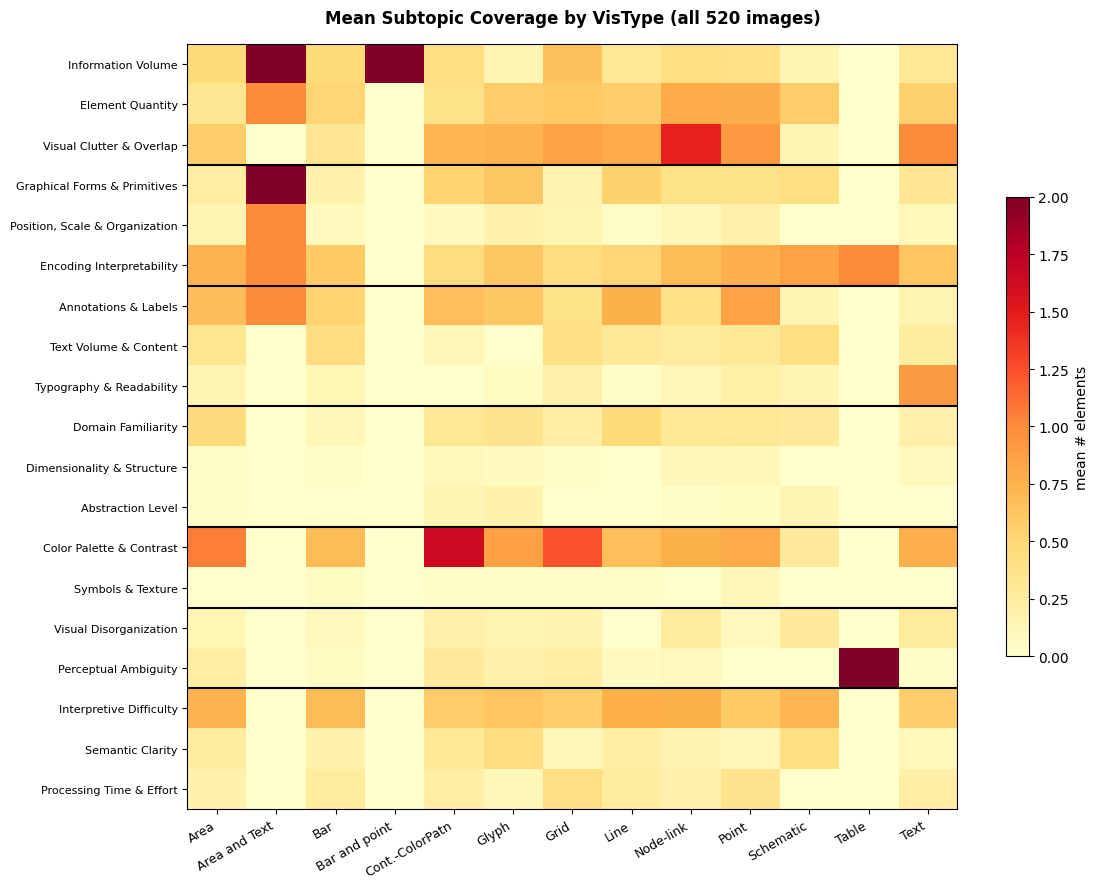

Saved heatmap to vc_genome_output_full/subtopic_coverage_heatmap_by_vistype.png


In [21]:
all_subtopics = subtopics_df['SubTopic'].tolist()

# Per-image coverage counts
coverage_rows = []
for img, canon in stage2_canonical.items():
    hit = Counter()
    for a in canon['attributes']:
        hit[a['subtopic']] += 1
    for r in canon['relationships']:
        hit[r['subtopic']] += 1
    row_data = {'imageName': img}
    row_data.update({st: hit.get(st, 0) for st in all_subtopics})
    coverage_rows.append(row_data)

cov_df = pd.DataFrame(coverage_rows).set_index('imageName')
cov_df.to_csv(OUT_DIR / 'subtopic_coverage.csv')

# Merge with VisType and aggregate
cov_merged = cov_df.merge(compiled[['imageName', 'VisType']].set_index('imageName'),
                           left_index=True, right_index=True)
vt_means = cov_merged.groupby('VisType')[all_subtopics].mean()

fig, ax = plt.subplots(figsize=(max(10, len(vt_means) * 0.9), 9))
im = ax.imshow(vt_means.T.values, cmap='YlOrRd', aspect='auto', interpolation='nearest')

ax.set_xticks(range(len(vt_means)))
ax.set_xticklabels(vt_means.index, rotation=30, ha='right', fontsize=9)
ax.set_yticks(range(len(all_subtopics)))
ax.set_yticklabels(all_subtopics, fontsize=8)

prev_topic = None
for i, st in enumerate(all_subtopics):
    topic = subtopics_df.loc[subtopics_df['SubTopic'] == st, 'Topic'].values[0]
    if prev_topic and topic != prev_topic:
        ax.axhline(y=i - 0.5, color='black', linewidth=1.5)
    prev_topic = topic

ax.set_title('Mean Subtopic Coverage by VisType (all 520 images)',
             fontsize=12, fontweight='bold', pad=15)
plt.colorbar(im, ax=ax, label='mean # elements', shrink=0.6)
plt.tight_layout()
fig.savefig(OUT_DIR / 'subtopic_coverage_heatmap_by_vistype.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved heatmap to {OUT_DIR}/subtopic_coverage_heatmap_by_vistype.png')

## Output Summary

In [22]:
print('=== VC-Genome Full Pipeline Output ===')
print(f'Images processed: {len(metrics_df)}')
print(f'VisTypes covered: {metrics_df["VisType"].nunique()}')
svg_count = len(list(GRAPH_DIR.glob('*.svg')))
png_count = len(list(PNG_DIR.glob('*.png')))
print(f'SVGs saved:       {svg_count}')
print(f'PNGs saved:       {png_count}')
print(f'\nFiles in {OUT_DIR}/:')
for f in sorted(OUT_DIR.glob('*')):

    if f.is_file():        print(f'  {f.name:45s} {f.stat().st_size:>9,d} bytes')

=== VC-Genome Full Pipeline Output ===
Images processed: 520
VisTypes covered: 13
SVGs saved:       520
PNGs saved:       520

Files in vc_genome_output_full/:
  graph_metrics.csv                                30,731 bytes
  llm_extractions_api.json                      1,144,339 bytes
  llm_extractions_vision.json                     802,526 bytes
  subtopic_coverage.csv                            30,228 bytes
  subtopic_coverage_heatmap_by_vistype.png        122,834 bytes
